(cost-income-tutorial)=
# Measure cash flows with `CostIncome`

This notebook introduces the `CostIncome` class from CLIMADA, which is used to model the financial cash flows of adaptation or risk-reduction measures over time.

A `CostIncome` object tracks:
- **Initial (one-off) costs** — the upfront implementation cost
- **Periodic costs** — recurring expenses (e.g., maintenance)
- **Periodic income** — recurring revenues (e.g., insurance savings, avoided losses)
- **Growth rates** — how costs and incomes evolve over time
- **Custom cash flows** — arbitrary user-defined flows (layered on top)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust the import path if running outside the CLIMADA package tree
from climada.entity.measures.cost_income import CostIncome

## Quickstart

The simplest way to create a `CostIncome` is by passing keyword arguments directly.

| Parameter | Meaning | Sign convention |
|---|---|---|
| `init_cost` | One-off implementation cost | stored negative |
| `periodic_cost` | Recurring cost each period | stored negative |
| `periodic_income` | Recurring income each period | stored positive |
| `mkt_price_year` | Reference year for price levels | — |
| `freq` | Period frequency (e.g. `'Y'`, `'M'`, `'Q'`) | — |

```{note} **Sign convention**
`CostIncome` stores costs as negative numbers internally.
```

```{note}
Financial values in `CostIncome` are currently unitless (no currency is specified)
```

In [2]:
ci = CostIncome(
    mkt_price_year=2020,
    init_cost=20_000,  # 50 000 upfront
    periodic_cost=5_000,  # 5 000 / year maintenance
    periodic_income=12_000,  # 8 000 / year in avoided losses
    freq="Y",  # annual cash flows
)

print(ci)

CostIncome(
  mkt_price_year          = 2020
  freq                    = 'Y'
  init_cost               = -20,000.00
  periodic_cost           = -5,000.00
  periodic_income         = 12,000.00
  cost_yearly_growth_rate = 0.00%
  income_yearly_growth_rate = 0.00%
  custom_cash_flows       = None
)


## Calculating cash flows

Three methods are available:

| Method | Returns |
|---|---|
| `calc_cash_flows(impl_date, start_date, end_date)` | Three `np.ndarray`: net, costs, incomes |
| `calc_total(...)` | Three scalars: summed net, cost, income |
| `to_dataframe(...)` | A tidy `pd.DataFrame` |

The `impl_date` is when the measure is *deployed*. Cash flows before this date are zero; the initial cost lands on `impl_date`; periodic flows start the following period.

In [3]:
impl_date = "2022-01-01"
start_date = "2020-01-01"
end_date = "2030-01-01"

net, costs, incomes = ci.calc_cash_flows(impl_date, start_date, end_date)

print("Period  | Net       | Cost      | Income")
print("-" * 45)
periods = pd.period_range(start=start_date, end=end_date, freq="Y")
for p, n, c, i in zip(periods, net, costs, incomes):
    print(f"{p}  | {n:>9.0f} | {c:>9.0f} | {i:>6.0f}")

Period  | Net       | Cost      | Income
---------------------------------------------
2020  |         0 |         0 |      0
2021  |         0 |         0 |      0
2022  |    -20000 |    -20000 |      0
2023  |      7000 |     -5000 |  12000
2024  |      7000 |     -5000 |  12000
2025  |      7000 |     -5000 |  12000
2026  |      7000 |     -5000 |  12000
2027  |      7000 |     -5000 |  12000
2028  |      7000 |     -5000 |  12000
2029  |      7000 |     -5000 |  12000
2030  |      7000 |     -5000 |  12000


In [4]:
total_net, total_cost, total_income = ci.calc_total(impl_date, start_date, end_date)
print(f"Total net    : {total_net:>10.0f}")
print(f"Total cost   : {total_cost:>10.0f}")
print(f"Total income : {total_income:>10.0f}")

Total net    :      36000
Total cost   :     -60000
Total income :      96000


In [5]:
df = ci.to_dataframe(impl_date, start_date, end_date)
df

,date,net,cost,income
0,2020,0.0,0.0,0.0
1,2021,0.0,0.0,0.0
2,2022,-20000.0,-20000.0,0.0
3,2023,7000.0,-5000.0,12000.0
4,2024,7000.0,-5000.0,12000.0
5,2025,7000.0,-5000.0,12000.0
6,2026,7000.0,-5000.0,12000.0
7,2027,7000.0,-5000.0,12000.0
8,2028,7000.0,-5000.0,12000.0
9,2029,7000.0,-5000.0,12000.0


## Visualising cash flows

`plot_cash_flows` draws a bar chart. You can choose which series to display via the `to_plot` argument.

(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

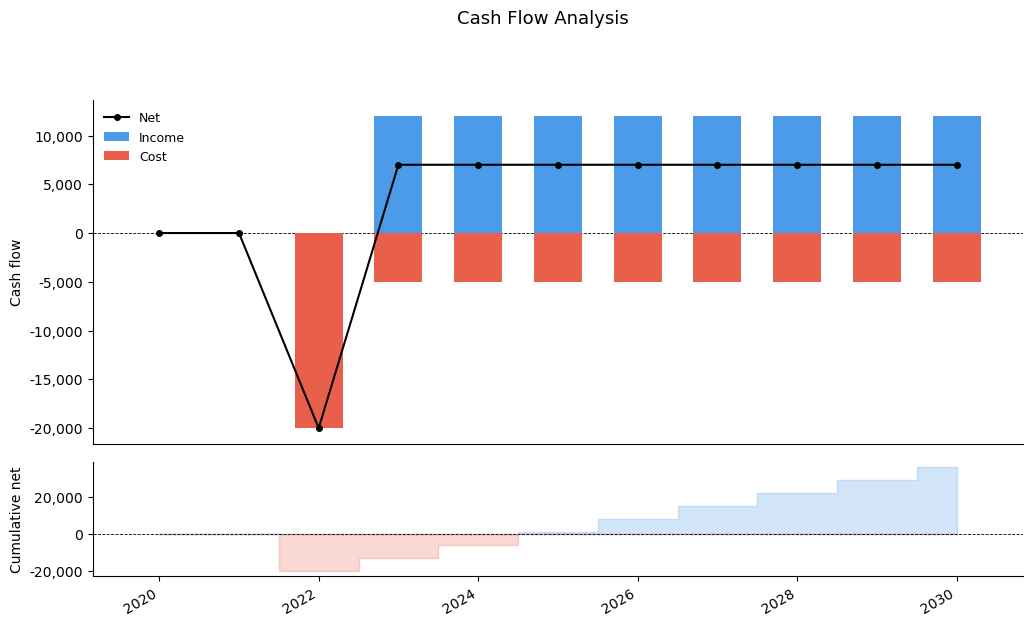

In [6]:
ci.plot_cash_flows(
    impl_date,
    start_date,
    end_date,
)

## Growth rates

Costs and incomes can grow year-over-year using compound-interest factors anchored to `mkt_price_year`.

$$\text{value}(t) = \text{base} \times (1 + r)^{\frac{t - t_0}{365}}$$

Pass `cost_yearly_growth_rate` and / or `income_yearly_growth_rate` (as decimals, e.g. `0.02` for 2 %).

(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

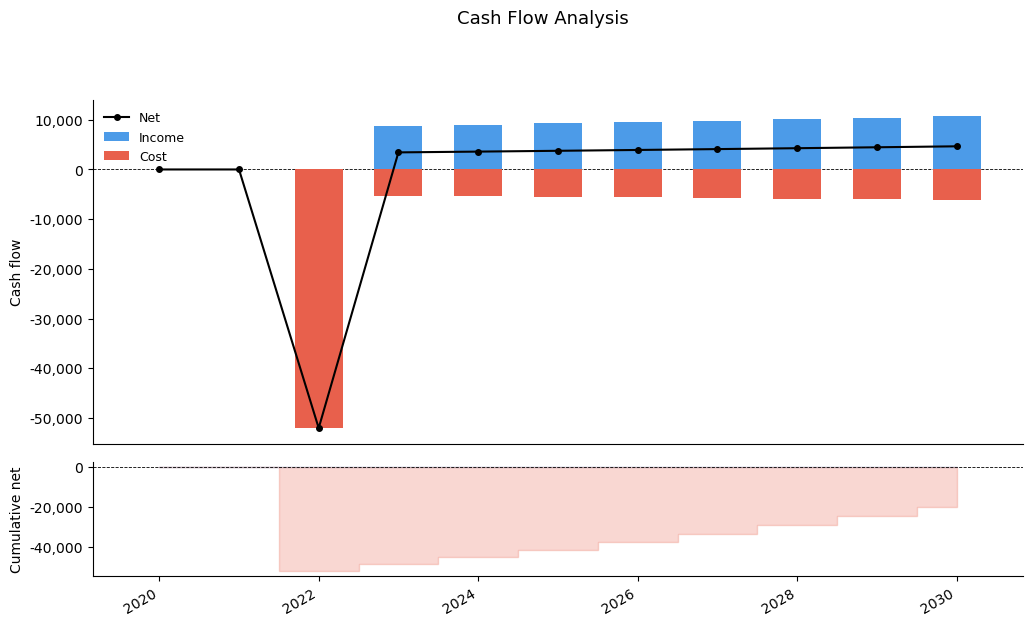

In [7]:
ci_growth = CostIncome(
    mkt_price_year=2020,
    init_cost=50_000,
    periodic_cost=5_000,
    periodic_income=8_000,
    cost_yearly_growth_rate=0.02,  # costs grow 2% / year
    income_yearly_growth_rate=0.03,  # income grows 3% / year
    freq="Y",
)

ci_growth.plot_cash_flows(impl_date, start_date, end_date)

In [8]:
# Compare totals with and without growth
no_growth = ci.calc_total(impl_date, start_date, end_date)
with_growth = ci_growth.calc_total(impl_date, start_date, end_date)

labels = ["Net", "Cost", "Income"]
print(f"{'':15s} {'No growth':>12s} {'With growth':>12s}")
for label, ng, wg in zip(labels, no_growth, with_growth):
    print(f"{label:15s} {ng:>12.0f} {wg:>12.0f}")

                   No growth  With growth
Net                    36000       -19821
Cost                  -60000       -97569
Income                 96000        77748


## Custom cash flows

For irregular or one-off flows, pass a `pd.DataFrame` with columns `date`, `cost`, and/or `income`.

These are **added on top** of any periodic amounts; dates not present in the DataFrame simply contribute zero.

In [9]:
custom_flows = pd.DataFrame(
    {
        "date": ["2024-01-01", "2026-01-01", "2028-01-01"],
        "cost": [10_000, 0, 20_000],  # extra one-off costs
        "income": [0, 15_000, 0],  # extra one-off income
    }
)

ci_custom = CostIncome(
    mkt_price_year=2020,
    init_cost=50_000,
    periodic_cost=5_000,
    periodic_income=8_000,
    custom_cash_flows=custom_flows,
    freq="Y",
)
ci_custom.to_dataframe(impl_date, start_date, end_date)

,date,net,cost,income
0,2020,0.0,0.0,0.0
1,2021,0.0,0.0,0.0
2,2022,-50000.0,-50000.0,0.0
3,2023,3000.0,-5000.0,8000.0
4,2024,-7000.0,-15000.0,8000.0
5,2025,3000.0,-5000.0,8000.0
6,2026,18000.0,-5000.0,23000.0
7,2027,3000.0,-5000.0,8000.0
8,2028,-17000.0,-25000.0,8000.0
9,2029,3000.0,-5000.0,8000.0


(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

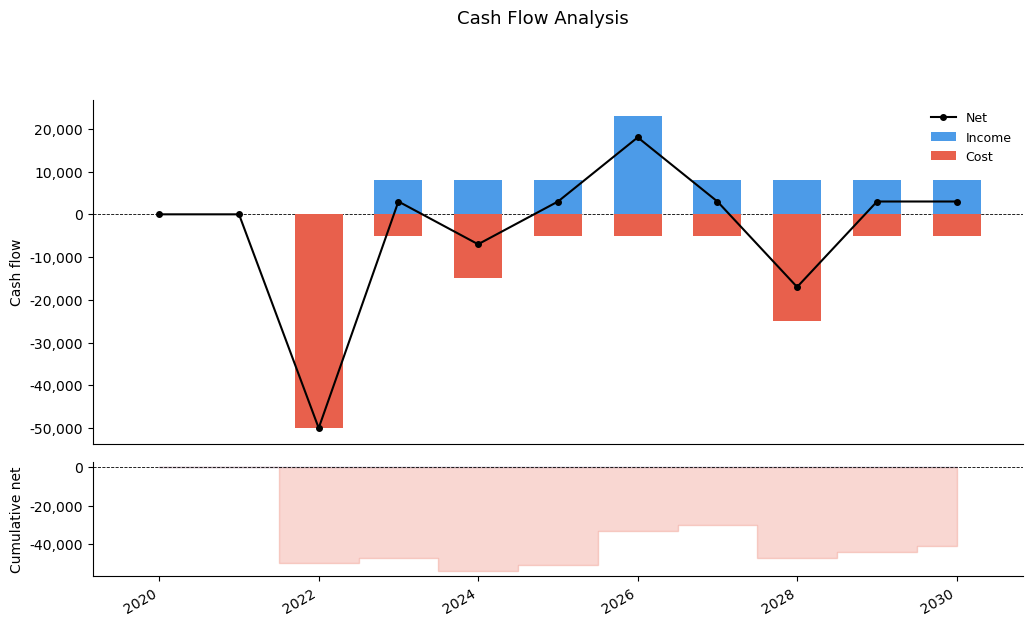

In [10]:
ci_custom.plot_cash_flows(impl_date, start_date, end_date)

## Sub-annual frequencies

`freq` accepts any pandas-compatible period string. Common options:

| `freq` | Meaning |
|---|---|
| `"Y"` | Annual |
| `"Q"` | Quarterly |
| `"M"` | Monthly |
| `"7D"` | Every 7 days |

```{note}
The periodic amounts are interpreted as **per-period** values, not annualised.
```

In [11]:
ci_monthly = CostIncome(
    mkt_price_year=2022,
    init_cost=5_000,
    periodic_cost=500,
    periodic_income=700,
    freq="M",
)

df_monthly = ci_monthly.to_dataframe(
    impl_date="2022-01-01",
    start_date="2022-01-01",
    end_date="2022-12-01",
)
df_monthly

,date,net,cost,income
0,2022-01,-5000.0,-5000.0,0.0
1,2022-02,200.0,-500.0,700.0
2,2022-03,200.0,-500.0,700.0
3,2022-04,200.0,-500.0,700.0
4,2022-05,200.0,-500.0,700.0
5,2022-06,200.0,-500.0,700.0
6,2022-07,200.0,-500.0,700.0
7,2022-08,200.0,-500.0,700.0
8,2022-09,200.0,-500.0,700.0
9,2022-10,200.0,-500.0,700.0


(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

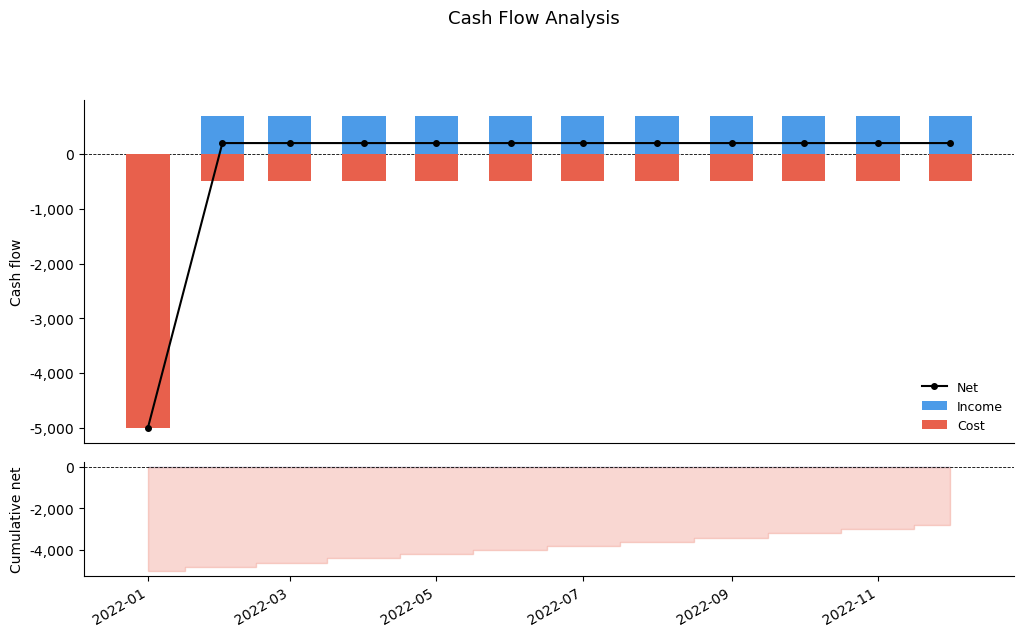

In [12]:
ci_monthly.plot_cash_flows(
    "2022-01-01",
    "2022-01-01",
    "2022-12-01",
)

## Combining multiple CostIncome objects

`CostIncome.comb_cost_income()` aggregates a list of `CostIncome` objects into a single one by summing costs and incomes.

```{warning}
All objects must share the same `mkt_price_year`, `cost_growth_rate`, and `income_growth_rate`.
```

```{note}
`custom_cash_flows` are **not** carried over to the combined object. Merge custom flows manually beforehand if needed.
```

In [13]:
ci_a = CostIncome(
    mkt_price_year=2020,
    init_cost=30_000,
    periodic_cost=2_000,
    periodic_income=4_000,
    freq="Y",
)

ci_b = CostIncome(
    mkt_price_year=2020,
    init_cost=20_000,
    periodic_cost=3_000,
    periodic_income=4_000,
    freq="Y",
)

ci_combined = CostIncome.comb_cost_income([ci_a, ci_b])

print(ci_combined)

CostIncome(
  mkt_price_year          = 2020
  freq                    = 'Y'
  init_cost               = -50,000.00
  periodic_cost           = -5,000.00
  periodic_income         = 8,000.00
  cost_yearly_growth_rate = 0.00%
  income_yearly_growth_rate = 0.00%
  custom_cash_flows       = None
)


## Loading from dict / YAML

### From a Python dictionary

In [14]:
config_dict = {
    "mkt_price_year": 2020,
    "init_cost": 50_000,
    "periodic_cost": 5_000,
    "periodic_income": 8_000,
    "cost_yearly_growth_rate": 0.02,
    "income_yearly_growth_rate": 0.03,
    "freq": "Y",
}

ci_from_dict = CostIncome.from_dict(config_dict)
print(ci_from_dict)

CostIncome(
  mkt_price_year          = 2020
  freq                    = 'Y'
  init_cost               = -50,000.00
  periodic_cost           = -5,000.00
  periodic_income         = 8,000.00
  cost_yearly_growth_rate = 2.00%
  income_yearly_growth_rate = 3.00%
  custom_cash_flows       = None
)


### From a YAML file

Create a YAML file structured as follows, then load it with `CostIncome.from_yaml`.

```yaml
# measure_cost.yaml
cost_income:
  mkt_price_year: 2020
  init_cost: 50000
  periodic_cost: 5000
  periodic_income: 8000
  cost_yearly_growth_rate: 0.02
  income_yearly_growth_rate: 0.03
  freq: "Y"
  # Optional custom flows:
  # custom_cash_flows:
  #   - date: "2024-01-01"
  #     cost: 10000
  #     income: 0
```